# Parametric Drive T1 Analysis

This notebook reads and visualizes the parametric drive T1 data from the .h5 file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set plotting style
# plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
from qcat.parser.qm_reader import load_xarray_h5, repetition_data
from qcat.utilities.simple_visualization import plot_2d_colormap_from_h5


In [13]:
# Define the path to the h5 file
h5_file_folder = [r"d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1164_LCH_qubit_parametric_drive_time_144006",
    r"d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1167_LCH_qubit_parametric_drive_time_144438",
    r"d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1169_LCH_qubit_parametric_drive_time_144710"]

target_frequencies = ([3.0555e8, 3.0055e8] ,[3.2355e8, 3.22555e8], [3.4405e8, 3.4305e8])

h5_file_path = [folder + r"\ds_raw.h5" for folder in h5_file_folder]

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Check if files exist
for i, path in enumerate(h5_file_path):
    if os.path.exists(path):
        print(f"Found h5 file {i+1}: {path}")
    else:
        print(f"File {i+1} not found: {path}")

Found h5 file 1: d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1164_LCH_qubit_parametric_drive_time_144006\ds_raw.h5
Found h5 file 2: d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1167_LCH_qubit_parametric_drive_time_144438\ds_raw.h5
Found h5 file 3: d:\github\ASQMDriver\data\2Q1C_17\2026-01-27\#1169_LCH_qubit_parametric_drive_time_144710\ds_raw.h5


In [15]:
# Load data from all files using the qcat parser
all_datasets = []
all_qubit_data = []

for i, file_path in enumerate(h5_file_path):
    try:
        ds = load_xarray_h5(file_path)
        print(f"\nSuccessfully loaded dataset {i+1} with dimensions: {dict(ds.dims)}")
        print(f"Coordinates: {list(ds.coords.keys())}")
        print(f"Data variables: {list(ds.data_vars.keys())}")
        
        # Check if it has multiple qubits/repetitions
        if 'qubit' in ds.dims:
            print(f"Found {ds.sizes['qubit']} qubits in the dataset")
            qubit_data = repetition_data(ds, repetition_dim="qubit")
            print(f"Separated data into {len(qubit_data)} individual qubit datasets")
        else:
            qubit_data = [ds]  # Single dataset
            print("Single dataset (no qubit dimension)")
        
        all_datasets.append(ds)
        all_qubit_data.append(qubit_data)
        
    except Exception as e:
        print(f"Error loading file {i+1}: {e}")
        all_datasets.append(None)
        all_qubit_data.append(None)

print(f"\nLoaded {len([d for d in all_datasets if d is not None])} out of {len(h5_file_path)} files successfully.")


Successfully loaded dataset 1 with dimensions: {'driving_frequency': 51, 'driving_time': 50, 'qubit': 1}
Coordinates: ['driving_frequency', 'driving_time', 'qubit']
Data variables: ['state']
Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets

Successfully loaded dataset 2 with dimensions: {'driving_frequency': 51, 'driving_time': 50, 'qubit': 1}
Coordinates: ['driving_frequency', 'driving_time', 'qubit']
Data variables: ['state']
Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets

Successfully loaded dataset 3 with dimensions: {'driving_frequency': 51, 'driving_time': 50, 'qubit': 1}
Coordinates: ['driving_frequency', 'driving_time', 'qubit']
Data variables: ['state']
Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets

Loaded 3 out of 3 files successfully.


C:\Users\shiau\AppData\Local\Temp\ipykernel_52776\512384649.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nSuccessfully loaded dataset {i+1} with dimensions: {dict(ds.dims)}")
C:\Users\shiau\AppData\Local\Temp\ipykernel_52776\512384649.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nSuccessfully loaded dataset {i+1} with dimensions: {dict(ds.dims)}")
C:\Users\shiau\AppData\Local\Temp\ipykernel_52776\512384649.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `

Creating combined 1D line plots with 6 lines (3 sets)...

Processing q1 from file 1
  Line 1: 3.0554 GHz (requested: 3.0555 GHz) - Dashed
  Line 2: 3.0450 GHz (requested: 3.0055 GHz) - Solid

Processing q1 from file 2
  Line 3: 3.2354 GHz (requested: 3.2355 GHz) - Dashed
  Line 4: 3.2254 GHz (requested: 3.2256 GHz) - Solid

Processing q1 from file 3
  Line 5: 3.4404 GHz (requested: 3.4405 GHz) - Dashed
  Line 6: 3.4304 GHz (requested: 3.4305 GHz) - Solid


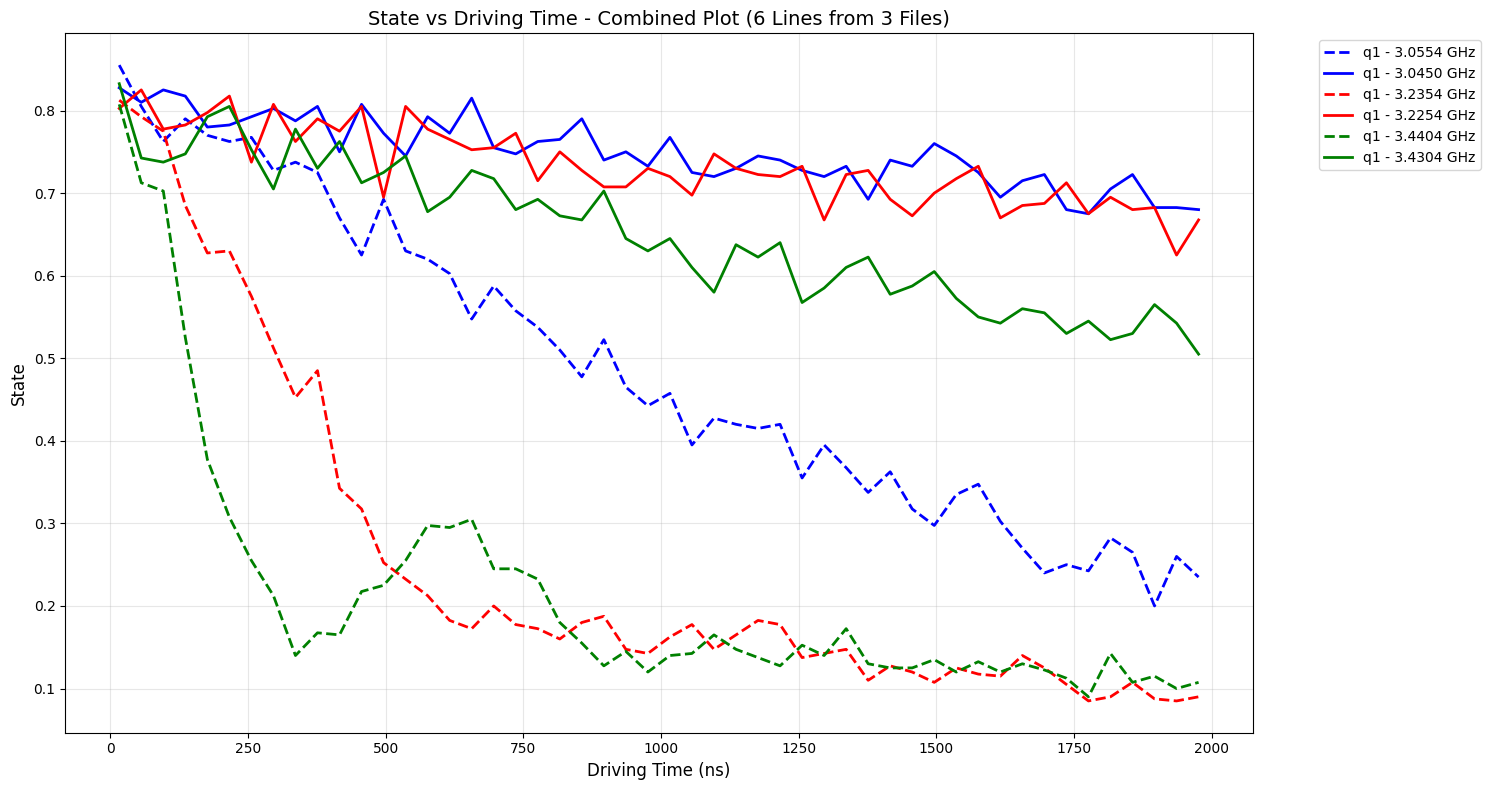


Combined plot creation complete! Plotted 6 lines total.


In [16]:
# Plot 6 lines (3 sets) on the same plot - each set from different files with their own target frequencies
if any(d is not None for d in all_datasets):
    print("Creating combined 1D line plots with 6 lines (3 sets)...")
    
    # Create a single figure for all lines
    plt.figure(figsize=(15, 8))
    
    # Define colors for different files
    colors = ['blue', 'red', 'green']
    
    line_count = 0
    
    # Loop through each file's data
    for file_idx, (dataset, qubit_data_list) in enumerate(zip(all_datasets, all_qubit_data)):
        if dataset is None or qubit_data_list is None:
            print(f"Skipping file {file_idx + 1} due to loading error")
            continue
            
        # Get target frequencies for this file
        current_target_frequencies = target_frequencies[file_idx]
        
        # Process the first qubit/dataset from this file
        sq_data = qubit_data_list[0]  # Take the first qubit data
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"File_{file_idx+1}"
        except:
            qubit_name = f"File_{file_idx+1}"
            
        print(f"\nProcessing {qubit_name} from file {file_idx + 1}")
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Plot 2 lines for each target frequency in this file
        for freq_idx, freq in enumerate(current_target_frequencies):
            # Find closest frequency in the data
            freq_idx_data = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx_data]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx_data).values
            
            # Set line style: first frequency = dashed, second frequency = solid
            line_style = '--' if freq_idx == 0 else '-'
            color = colors[file_idx]
            
            plt.plot(driving_time, state_data, 
                    linestyle=line_style,
                    color=color,
                    label=f'{qubit_name} - {actual_freq/1e8:.4f} GHz', 
                    linewidth=2)
            
            line_count += 1
            print(f"  Line {line_count}: {actual_freq/1e8:.4f} GHz (requested: {freq/1e8:.4f} GHz) - {'Dashed' if freq_idx == 0 else 'Solid'}")
    
    # Format the combined plot
    plt.xlabel('Driving Time (ns)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title('State vs Driving Time - Combined Plot (6 Lines from 3 Files)', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nCombined plot creation complete! Plotted {line_count} lines total.")
else:
    print("No data available for plotting.")

Performing T1 exponential decay fitting...

Analyzing qubit from file 1: q1
Frequency: 3.045 GHz
  T1 (τ): 3446.4 ns
  Amplitude: 0.2861
  Offset: 0.5325
  R²: 0.7853
Frequency: 3.045 GHz
  T1 (τ): 3446.4 ns
  Amplitude: 0.2861
  Offset: 0.5325
  R²: 0.7853


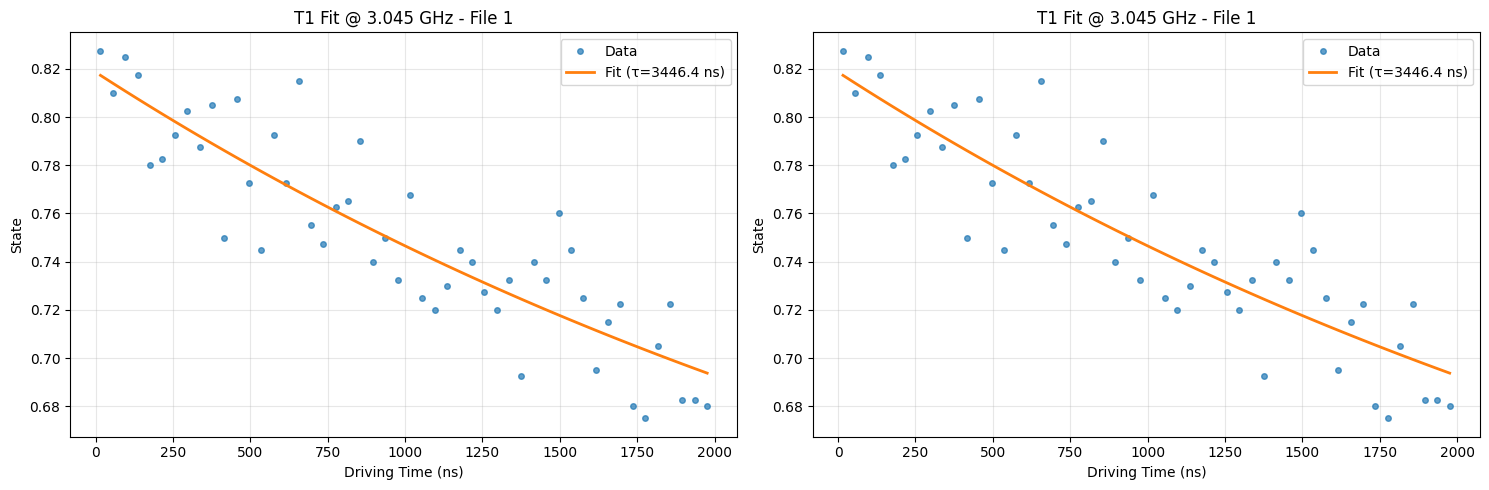


T1 Summary for q1 (File 1):
Frequency (GHz) | T1 (ns) | R²
-----------------------------------
      3.045 |  3446.4 | 0.7853
      3.045 |  3446.4 | 0.7853

Analyzing qubit from file 2: q1
Frequency: 3.225 GHz
  T1 (τ): 905.9 ns
  Amplitude: 0.1349
  Offset: 0.6799
  R²: 0.7112
Frequency: 3.225 GHz
  T1 (τ): 905.9 ns
  Amplitude: 0.1349
  Offset: 0.6799
  R²: 0.7112


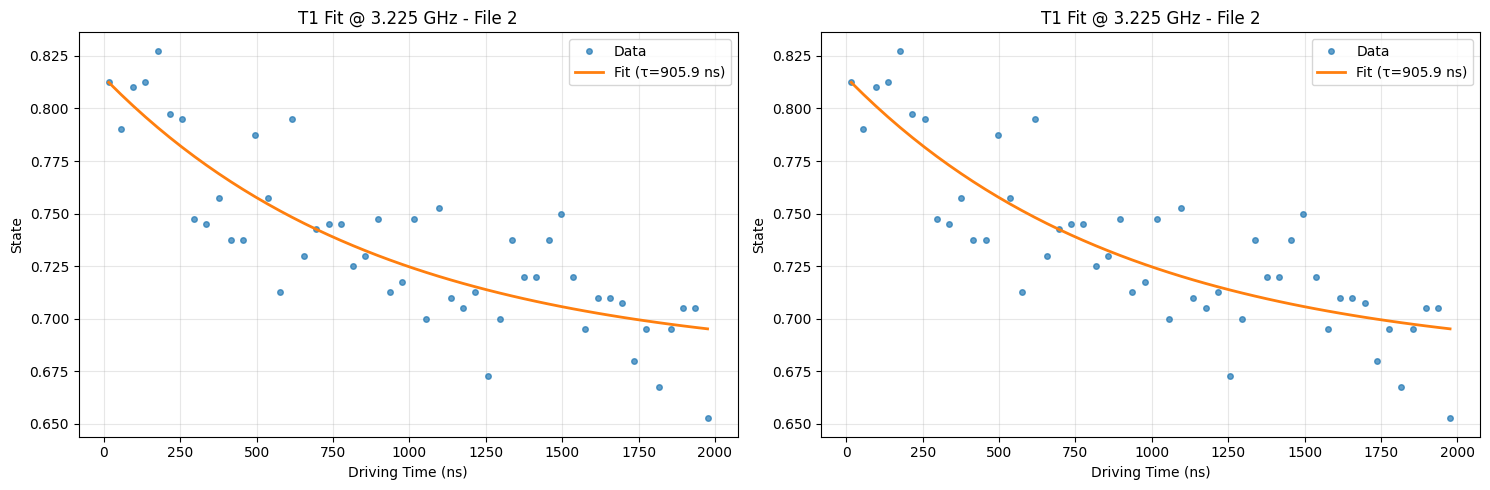


T1 Summary for q1 (File 2):
Frequency (GHz) | T1 (ns) | R²
-----------------------------------
      3.225 |   905.9 | 0.7112
      3.225 |   905.9 | 0.7112

Analyzing qubit from file 3: q1
Frequency: 3.430 GHz
  T1 (τ): 3092.2 ns
  Amplitude: 0.5740
  Offset: 0.2225
  R²: 0.9249
Frequency: 3.430 GHz
  T1 (τ): 3092.2 ns
  Amplitude: 0.5740
  Offset: 0.2225
  R²: 0.9249


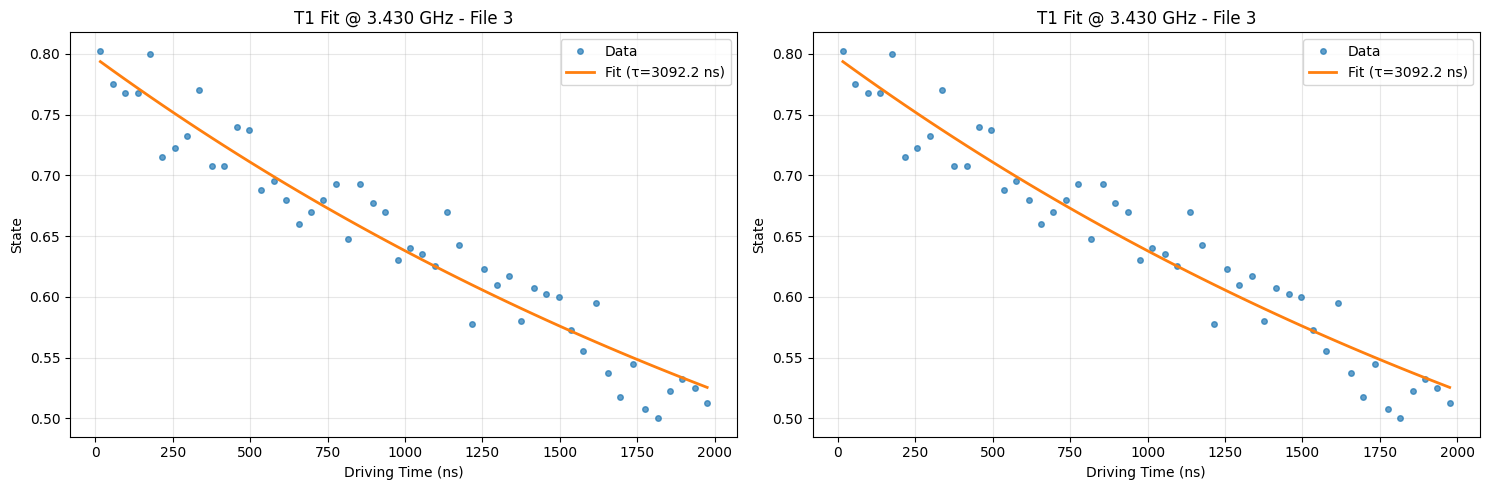


T1 Summary for q1 (File 3):
Frequency (GHz) | T1 (ns) | R²
-----------------------------------
      3.430 |  3092.2 | 0.9249
      3.430 |  3092.2 | 0.9249

T1 fitting analysis complete!


In [12]:
# T1 fitting using exponential decay
import xarray as xr
from qcat.utilities.function_fitting.fit_exp_decay import FitExponentialDecay

if any(d is not None for d in all_datasets):
    print("Performing T1 exponential decay fitting...")
    
    # User-specified driving frequencies for T1 analysis
    t1_target_frequencies = [0.5e8, 1e8]  # Modify this list as needed
    
    # Loop through each file's data
    for file_idx, (dataset, qubit_data_list) in enumerate(zip(all_datasets, all_qubit_data)):
        if dataset is None or qubit_data_list is None:
            print(f"Skipping file {file_idx + 1} due to loading error")
            continue
        
        # Process the first qubit/dataset from this file
        sq_data = qubit_data_list[0]  # Take the first qubit data
        
        try:
            qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"File_{file_idx+1}"
            print(f"\nAnalyzing qubit from file {file_idx + 1}: {qubit_name}")
        except:
            print(f"\nAnalyzing dataset from file {file_idx + 1}")
        
        # Get driving_time and driving_frequency arrays
        driving_time = sq_data.coords["driving_time"].values
        driving_freq = sq_data.coords["driving_frequency"].values
        
        # Create subplot for fitted curves
        plt.figure(figsize=(15, 5))
        
        # Results storage
        fit_results = []
        
        # Fit exponential decay for each target frequency
        for j, freq in enumerate(t1_target_frequencies):
            plt.subplot(1, len(t1_target_frequencies), j+1)
            
            # Find closest frequency in the data
            freq_idx = np.argmin(np.abs(driving_freq - freq))
            actual_freq = driving_freq[freq_idx]
            
            # Extract state data for this frequency
            state_data = sq_data["state"].isel(driving_frequency=freq_idx).values
            
            # Create DataArray for fitting (fitter expects "x" coordinate)
            fit_data = xr.DataArray(
                state_data,
                coords={"x": driving_time},
                dims=["x"]
            )
            
            # Perform fitting
            fitter = FitExponentialDecay(fit_data)
            result = fitter.fit()
            
            # Extract fitted parameters
            a = result.params['a'].value
            tau = result.params['tau'].value
            c = result.params['c'].value
            
            # Store results
            fit_results.append({
                'frequency': actual_freq,
                'amplitude': a,
                'tau': tau,
                'offset': c,
                'r_squared': 1 - result.residual.var() / np.var(state_data)
            })
            
            # Plot data and fit
            plt.plot(driving_time, state_data, 'o', alpha=0.7, label='Data', markersize=4)
            plt.plot(driving_time, result.best_fit, '-', linewidth=2, label=f'Fit (τ={tau:.1f} ns)')
            
            plt.xlabel('Driving Time (ns)')
            plt.ylabel('State')
            plt.title(f'T1 Fit @ {actual_freq/1e8:.3f} GHz - File {file_idx+1}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            print(f"Frequency: {actual_freq/1e8:.3f} GHz")
            print(f"  T1 (τ): {tau:.1f} ns")
            print(f"  Amplitude: {a:.4f}")
            print(f"  Offset: {c:.4f}")
            print(f"  R²: {1 - result.residual.var() / np.var(state_data):.4f}")
        
        plt.tight_layout()
        plt.show()
        
        # Summary table
        print(f"\nT1 Summary for {qubit_name} (File {file_idx+1}):")
        print("Frequency (GHz) | T1 (ns) | R²")
        print("-" * 35)
        for res in fit_results:
            print(f"{res['frequency']/1e8:11.3f} | {res['tau']:7.1f} | {res['r_squared']:.4f}")
    
    print("\nT1 fitting analysis complete!")
else:
    print("No data available for T1 fitting.")